# Рубежный контроль №1

**Студент:** Поляков Леонид

**Группа:** ИУ5-62Б

**Вариант:** 17 (задача №3, датасет №1 — Iris)

**Доп. задание:** для произвольной колонки данных построить гистограмму

## Постановка задачи

Для заданного набора данных произвести:
* масштабирование данных для одного признака;
* преобразование категориального признака в количественный двумя способами: **Label Encoding** и **One-Hot Encoding**.

В наборе данных Iris отсутствуют категориальные признаки (целевая метка `target` — это номер класса, остальные четыре признака — вещественные измерения в сантиметрах). По условию задания, если в датасете нет категориальных признаков, их можно создать искусственно на основе числового признака. Воспользуемся этим: создадим категориальный признак на основе длины чашелистика.

## Импорт библиотек и загрузка данных

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

Загружаем датасет Iris из файла `iris.csv`, он был предварительно выгружен из `sklearn.datasets.load_iris`

In [ ]:
df = pd.read_csv('iris.csv')
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
print(f'Размер датасета: {df.shape}')
print(f'Колонки: {list(df.columns)}')
print(f'Типы данных:\n{df.dtypes}')
print(f'\nКоличество пропусков по колонкам:\n{df.isna().sum()}')
print(f'\nРаспределение целевого признака target:\n{df["target"].value_counts().sort_index()}')

Размер датасета: (150, 5)
Колонки: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target']
Типы данных:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
dtype: object

Количество пропусков по колонкам:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

Распределение целевого признака target:
target
0    50
1    50
2    50
Name: count, dtype: int64


In [ ]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


В датасете 150 наблюдений, 4 числовых признака и 1 целевой признак (`target` — номер класса: 0 — *setosa*, 1 — *versicolor*, 2 — *virginica*). Пропусков нет, классы сбалансированы (по 50 объектов каждого класса).

## Гистограмма

Построим гистограмму распределения для произвольной колонки — возьмём `petal length (cm)` (длина лепестка). Этот признак хорошо разделяет классы, поэтому распределение должно быть бимодальным/мультимодальным.

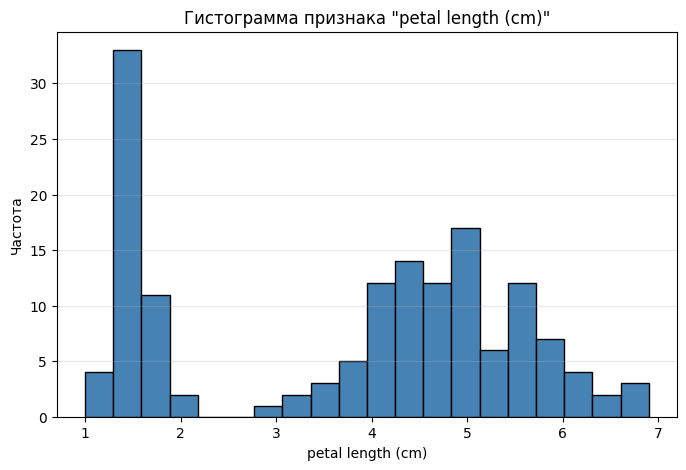

In [ ]:
column_for_hist = 'petal length (cm)'

plt.figure(figsize=(8, 5))
plt.hist(df[column_for_hist], bins=20, color='steelblue', edgecolor='black')
plt.xlabel(column_for_hist)
plt.ylabel('Частота')
plt.title(f'Гистограмма признака "{column_for_hist}"')
plt.grid(axis='y', alpha=0.3)
plt.show()

На гистограмме отчётливо видно две группы значений: компактный пик в районе 1–2 см (это класс *setosa*) и более широкое распределение в районе 3–7 см (классы *versicolor* и *virginica*). Это подтверждает, что `petal length (cm)` — сильный разделяющий признак.

## Создание категориального признака

В Iris нет категориальных признаков, поэтому создадим его искусственно. Разобьём числовой признак `sepal length (cm)` (длина чашелистика) на три равных интервала и присвоим им метки `short` / `medium` / `long`. Получится упорядоченный категориальный признак с тремя уровнями.

In [ ]:
df['sepal_length_cat'] = pd.cut(
    df['sepal length (cm)'],
    bins=3,
    labels=['short', 'medium', 'long']
)

print('Уникальные значения нового категориального признака:')
print(df['sepal_length_cat'].unique())
print('\nРаспределение по категориям:')
print(df['sepal_length_cat'].value_counts())
df.head()

Уникальные значения нового категориального признака:
['short', 'medium', 'long']
Categories (3, object): ['short' < 'medium' < 'long']

Распределение по категориям:
sepal_length_cat
medium    71
short     59
long      20
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,sepal_length_cat
0,5.1,3.5,1.4,0.2,0,short
1,4.9,3.0,1.4,0.2,0,short
2,4.7,3.2,1.3,0.2,0,short
3,4.6,3.1,1.5,0.2,0,short
4,5.0,3.6,1.4,0.2,0,short


## One-Hot Encoding

**Метод:** каждая уникальная категория превращается в отдельный бинарный признак-индикатор (0/1). Подходит для номинальных признаков, где нет естественного порядка между категориями. Минус — увеличивает размерность (если уникальных значений много).

Применим `OneHotEncoder` из `sklearn.preprocessing` к признаку `sepal_length_cat`.

In [ ]:
df_ohe = df.copy()

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe_array = ohe.fit_transform(df_ohe[['sepal_length_cat']])

ohe_df = pd.DataFrame(
    ohe_array,
    columns=ohe.get_feature_names_out(['sepal_length_cat']),
    index=df_ohe.index
)

df_ohe_final = pd.concat([df_ohe, ohe_df], axis=1)
df_ohe_final.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,sepal_length_cat,sepal_length_cat_long,sepal_length_cat_medium,sepal_length_cat_short
0,5.1,3.5,1.4,0.2,0,short,0.0,0.0,1.0
1,4.9,3.0,1.4,0.2,0,short,0.0,0.0,1.0
2,4.7,3.2,1.3,0.2,0,short,0.0,0.0,1.0
3,4.6,3.1,1.5,0.2,0,short,0.0,0.0,1.0
4,5.0,3.6,1.4,0.2,0,short,0.0,0.0,1.0


Получили три новых бинарных признака: `sepal_length_cat_short`, `sepal_length_cat_medium`, `sepal_length_cat_long`. У каждого объекта ровно один из них равен 1.

## Label Encoding

**Метод:** каждой категории сопоставляется целое число. Подходит для **порядковых** признаков (где категории можно естественно упорядочить), а также для целевой переменной в задачах классификации. Для номинальных признаков без порядка лучше не использовать — модель воспримет числовой порядок как смысловой.

Поскольку наш признак `sepal_length_cat` упорядоченный (`short < medium < long`), Label Encoding здесь уместен. Применим явный `mapper` через `pandas.Series.map` — это позволяет контролировать порядок меток (в отличие от `LabelEncoder` из sklearn, который сортирует значения по алфавиту).

In [ ]:
label_mapper = {
    'short': 0,
    'medium': 1,
    'long': 2
}

df['sepal_length_cat_label'] = df['sepal_length_cat'].map(label_mapper)
df[['sepal length (cm)', 'sepal_length_cat', 'sepal_length_cat_label']].head(10)

,sepal length (cm),sepal_length_cat,sepal_length_cat_label
0,5.1,short,0
1,4.9,short,0
2,4.7,short,0
3,4.6,short,0
4,5.0,short,0
5,5.4,short,0
6,4.6,short,0
7,5.0,short,0
8,4.4,short,0
9,4.9,short,0


Для сравнения получим тот же результат с помощью `LabelEncoder` из sklearn (порядок здесь будет лексикографический: `long=0, medium=1, short=2`, что не соответствует семантике, поэтому в реальной модели предпочтительнее `map`).

In [ ]:
le = LabelEncoder()
df['sepal_length_cat_le_sklearn'] = le.fit_transform(df['sepal_length_cat'])

print('Соответствие "категория → метка" у sklearn LabelEncoder:')
for cls, code in zip(le.classes_, le.transform(le.classes_)):
    print(f'  {cls!r:>10} -> {code}')

df[['sepal_length_cat', 'sepal_length_cat_label', 'sepal_length_cat_le_sklearn']].head()

Соответствие "категория → метка" у sklearn LabelEncoder:
      'long' -> 0
    'medium' -> 1
     'short' -> 2


,sepal_length_cat,sepal_length_cat_label,sepal_length_cat_le_sklearn
0,short,0,2
1,short,0,2
2,short,0,2
3,short,0,2
4,short,0,2


## Масштабирование признака (StandardScaler)

**Метод:** стандартизация (z-score) — `(x - mean) / std`. Приводит признак к распределению с нулевым средним и единичной дисперсией. Это подходит, когда признак распределён близко к нормальному и/или модель чувствительна к масштабам признаков (линейная регрессия, SVM, kNN, нейросети, методы с регуляризацией). Альтернатива — `MinMaxScaler` (приведение в диапазон [0,1]) для случаев, когда распределение далеко от нормального или важны границы.

Отмасштабируем признак `petal length (cm)`.

In [ ]:
scaler = StandardScaler()
df['petal_length_scaled'] = scaler.fit_transform(df[['petal length (cm)']])

df[['petal length (cm)', 'petal_length_scaled']].head()

,petal length (cm),petal_length_scaled
0,1.4,-1.340227
1,1.4,-1.340227
2,1.3,-1.397064
3,1.5,-1.283389
4,1.4,-1.340227


In [ ]:
print('Статистика исходного признака petal length (cm):')
print(df['petal length (cm)'].describe())
print('\nСтатистика стандартизованного признака:')
print(df['petal_length_scaled'].describe())

Статистика исходного признака petal length (cm):
count    150.000000
mean       3.758000
std        1.765298
min        1.000000
25%        1.600000
50%        4.350000
75%        5.100000
max        6.900000
Name: petal length (cm), dtype: float64

Статистика стандартизованного признака:
count    1.500000e+02
mean    -4.263256e-16
std      1.003350e+00
min     -1.567576e+00
25%     -1.226552e+00
50%      3.364776e-01
75%      7.627583e-01
max      1.785832e+00
Name: petal_length_scaled, dtype: float64


После стандартизации среднее ≈ 0, стандартное отклонение ≈ 1 — то, что мы и ожидали от `StandardScaler`.

## Итоговая таблица

In [ ]:
result_cols = [
    'sepal length (cm)',
    'sepal_length_cat',
    'sepal_length_cat_label',
    'petal length (cm)',
    'petal_length_scaled',
    'target',
]
df[result_cols].head(10)

,sepal length (cm),sepal_length_cat,sepal_length_cat_label,petal length (cm),petal_length_scaled,target
0,5.1,short,0,1.4,-1.340227,0
1,4.9,short,0,1.4,-1.340227,0
2,4.7,short,0,1.3,-1.397064,0
3,4.6,short,0,1.5,-1.283389,0
4,5.0,short,0,1.4,-1.340227,0
5,5.4,short,0,1.7,-1.169714,0
6,4.6,short,0,1.4,-1.340227,0
7,5.0,short,0,1.5,-1.283389,0
8,4.4,short,0,1.4,-1.340227,0
9,4.9,short,0,1.5,-1.283389,0


## Выводы

1. **Гистограмма.** Распределение `petal length (cm)` мультимодальное — это сразу подсказывает, что признак хорошо разделяет классы, что является косвенным аргументом в пользу его пригодности для построения классификационных моделей.
2. **One-Hot Encoding** применён через `sklearn.preprocessing.OneHotEncoder` — это универсальный способ кодирования номинальных категорий, не вносящий искусственного порядка. Он удобен, когда признак подаётся в линейные/логистические модели.
3. **Label Encoding** применён через `pandas.Series.map` с явным словарём порядка, потому что наш признак упорядоченный (`short < medium < long`). Это сохраняет семантику порядка в одном числовом столбце. Стандартный `LabelEncoder` из sklearn в данном случае хуже — он сортирует метки лексикографически и теряет правильный порядок.
4. **Стандартизация** через `StandardScaler` приводит признак к распределению с μ≈0, σ≈1, что нужно для моделей, чувствительных к масштабам (kNN, SVM, линейные модели с регуляризацией, нейросети). На исходных деревьях решений и градиентных бустингах масштабирование не требуется.